<a href="https://colab.research.google.com/github/sulthanalihsan/data-science-2026/blob/main/Pertemuan11_Muhamad_Sulthan_Al_Ihsan_250401020154.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PERTEMUAN 11: Unsupervised Learning:Clustering (K-Means & Hierarchical)
**Nama  :** Muhammad Sulthan Al Ihsan

**NIM   :** 250401020154

**Mata Kuliah:** Data Science —  S1 PJJ Informatika

**Kelas:** IF401

# Langkah 1: Generate & Eksplorasi Dataset

Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


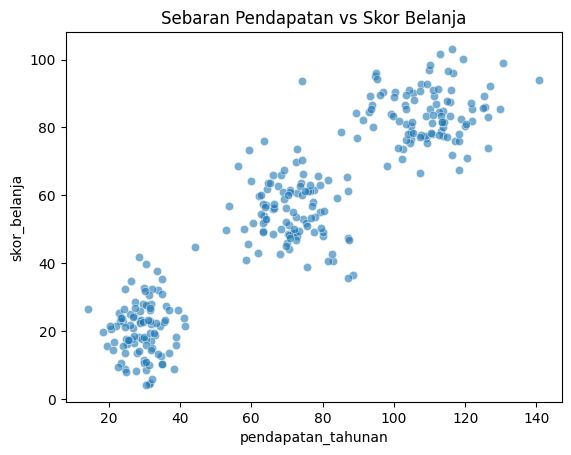

In [39]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)
grp1 = np.random.normal([30, 20], [6, 8], (100, 2)) # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2)) # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # boros
data = np.vstack([grp1, grp2, grp3])
df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))
print('Shape:', df.shape)
print(df.describe().round(2))
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.show()

Catatan : Bagian ini merupakan tahap awal untuk menyiapkan data simulasi pelanggan. Di sini, data dibuat secara otomatis untuk membentuk tiga kelompok perilaku belanja yang berbeda: kelompok hemat, menengah, dan boros.

Selain itu ditambahkan juga informasi variasi seperti usia dan jenis kelamina. Hasil ringkasan statistik menunjukkan rata-rata pendapatan berada di angka 69,96 dengan sebaran skor belanja yang cukup luas. Melalui visualisasi grafik titik (scatterplot), terlihat jelas adanya tiga bongkahan kelompok yang terpisah, yang nantinya akan menjadi target utama untuk dianalisis lebih lanjut menggunakan teknik pengelompokan (clustering).



---



# Langkah 2: Preprocessing Data

In [40]:
from sklearn.preprocessing import StandardScaler
X = df[['pendapatan_tahunan', 'skor_belanja']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling :', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling : [1. 1.]


Catatan : Bagian ini menjalankan proses agar variabel pendapatan dan skor belanja berada pada skala yang sama.

Setelah proses selesai, rata-rata data berubah menjadi nol dan standar deviasinya menjadi satu. Hal ini memastikan perbandingan antar variabel menjadi jadi seimbang, agar algoritma bekerja akurat



---



# Langkah 3: Metode Elbow untuk Menentukan K
Jalankan K-Means untuk K=1 hingga 10, simpan nilai WCSS setiap K, lalu plot grafik Elbow.
from sklearn.cluster i

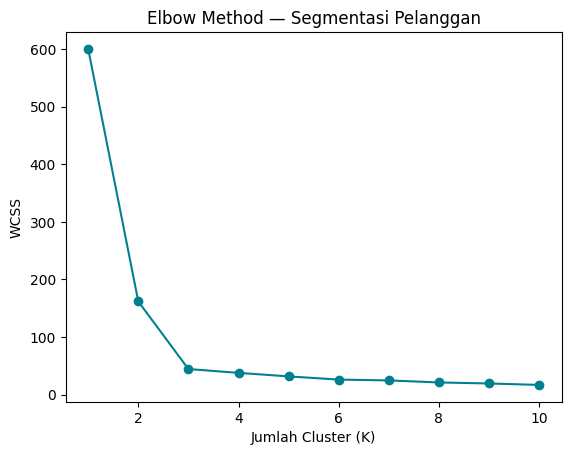

In [41]:
from sklearn.cluster import KMeans
wcss = []
for k in range(1, 11):
  km = KMeans(n_clusters=k, random_state=42, init='k-means++')
  km.fit(X_scaled)
  wcss.append(km.inertia_)
plt.plot(range(1, 11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster (K)'); plt.ylabel('WCSS')
plt.title('Elbow Method — Segmentasi Pelanggan')
plt.show()
# Interpretasikan dalam sel Markdown berikutnya:
# - Di K berapa kurva mulai melandai (titik elbow)?
# - Apakah hasilnya sesuai dengan jumlah kelompok yang diharapkan?

Catatan : Proses ini menggunakan metode Elbow untuk menentukan jumlah kelompok (K) yang paling pas bagi data pelanggan. Grafik menunjukkan penurunan nilai WCSS yang sangat tajam saat berpindah dari satu ke dua kelompok, lalu mulai melandai secara signifikan tepat setelah angka tiga.

Titik 'elbow' terlihat berada pada K=3. Hasil ini sesuai dengan jumlah kelompok yang sengaja dibuat di awal, yaitu kelompok hemat, menengah, dan boros. Dengan demikian, tiga kelompok menjadi pilihan terbaik untuk melakukan segmentasi pada data ini.



---




# Langkah 4: Melatih Model K-Means
Latih model K-Means dengan K optimal hasil pengamatan grafik Elbow, lalu tampilkan
koefisien evaluasinya.

In [42]:
from sklearn.metrics import silhouette_score
model = KMeans(n_clusters=3, random_state=42, init='k-means++')
model.fit(X_scaled)
df['cluster'] = model.labels_
print(f'WCSS akhir : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

WCSS akhir : 44.556
Silhouette Score: 0.695
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


Catatana : Cell ini menjalankan pelatihan model K-Means dengan membagi pelanggan ke dalam tiga kelompok utama. Skor Silhouette yang bernilai 0,695 menunjukkan bahwa pembagian kelompok sudah baik dan setiap data berada di kelompok yang tepat.

Hasil pengelompokan memperlihatkan perbedaan yang jelas: Kelompok 1 merupakan pelanggan dengan pendapatan rendah dan pengeluaran hemat. Kelompok 0 mewakili kelas menengah dengan perilaku belanja yang stabil. Sementara itu, Kelompok 2 diisi oleh pelanggan berpendapatan tinggi yang sangat boros. Statistik ini meenunjukan bahwa model berhasil mengenali karakteristik unik dari setiap segmen pelanggan dgn akurat.

# Langkah 5: Visualisasi Hasil Clustering
Buat scatter plot berwarna per cluster beserta posisi centroid, kemudian interpretasikan
karakteristik tiap segmen

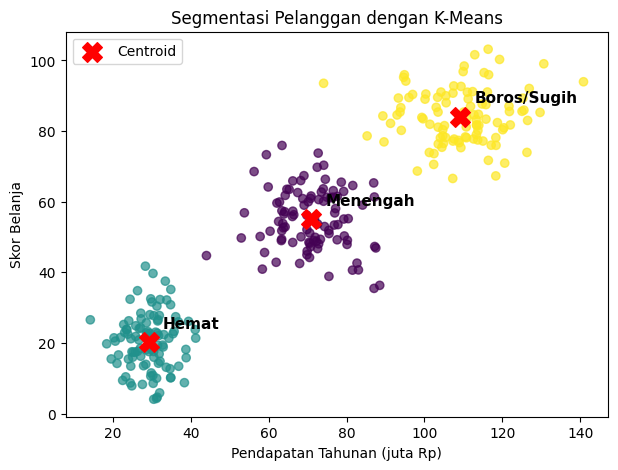

In [43]:
centroids = scaler.inverse_transform(model.cluster_centers_)
plt.figure(figsize=(7, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'],
  c=df['cluster'], cmap='viridis', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1],
  c='red', marker='X', s=200, label='Centroid')
# Anotasi label segmen berdasarkan urutan pendapatan
order = np.argsort(centroids[:, 0])
segment_names = ['Hemat', 'Menengah', 'Boros/Sugih']
for rank, cl in enumerate(order):
    plt.annotate(segment_names[rank], (centroids[cl,0], centroids[cl,1]),
                textcoords='offset points', xytext=(10,10),
                fontsize=11, fontweight='bold')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend(); plt.show()
# Interpretasikan tiap cluster, misalnya:
# Cluster 0 = pendapatan rendah, belanja rendah -> segmen 'Hemat'
# Cluster 1 = pendapatan menengah, belanja menengah -> segmen 'Menengah'
# Cluster 2 = pendapatan tinggi, belanja tinggi -> segmen 'Boros/Premium'

In [44]:
# Menghitung rata-rata per cluster untuk interpretasi
interpretasi = df.groupby('cluster').agg({
    'pendapatan_tahunan': 'mean',
    'skor_belanja': 'mean',
    'usia': 'count'
}).rename(columns={'usia': 'jumlah_pelanggan'}).reset_index()

# Menambahkan label status berdasarkan analisis sebelumnya
interpretasi['label'] = interpretasi['cluster'].map({
    1: 'Hemat (Pendapatan & Belanja Rendah)',
    0: 'Menengah (Pendapatan & Belanja Stabil)',
    2: 'Boros/Sugih (Pendapatan & Belanja Tinggi)'
})

# Menampilkan hasil interpretasi
print("Interpretasi Karakteristik Tiap Cluster:")
display(interpretasi.sort_values(by='pendapatan_tahunan'))

Interpretasi Karakteristik Tiap Cluster:


,cluster,pendapatan_tahunan,skor_belanja,jumlah_pelanggan,label
1,1,29.306614,20.272179,100,Hemat (Pendapatan & Belanja Rendah)
0,0,70.994733,55.050104,99,Menengah (Pendapatan & Belanja Stabil)
2,2,109.198842,84.084249,101,Boros/Sugih (Pendapatan & Belanja Tinggi)


Catatan : Berdasarkan letak persebaran titik-titiknya pada visual, tiga segmen pelanggan teridentifikasi dengan jelas:

Kelompok 0 (Segmen Menengah): Berada di tengah grafik, mewakili pelanggan dengan pendapatan dan pengeluaran yang rata-rata atau stabil. (pendapatan tahunan 70 jt, skor belanja 55)

Kelompok 1 (Segmen Hemat): Berkumpul di area kiri bawah, mencerminkan kelompok pelanggan dengan pendapatan rendah yang sangat berhati-hati dalam belanja.
(pendapatan tahunan 29 jt, skor belanja 20)

Kelompok 2 (Segmen Boros/Sugih): Terletak di area kanan atas, menunjukkan pelanggan berpendapatan tinggi yang memiliki intensitas belanja sangat besar.
(pendapatan tahunan 109 jt, skor belanja 84)



---



# Langkah 6: Hierarchical Clustering (Pembanding)
Sebagai pembanding, bangun dendrogram menggunakan Ward linkage dan bandingkan
hasilnya dengan K-Means.

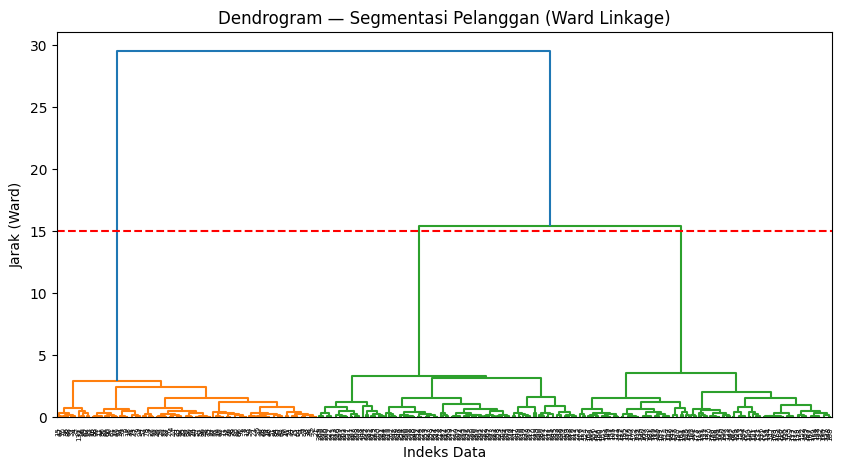

In [45]:
from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data'); plt.ylabel('Jarak (Ward)')
plt.axhline(y=15, color='red', linestyle='--') # contoh garis potong
plt.show()
# Bandingkan: apakah jumlah cluster dari dendrogram (garis potong)
# konsisten dengan K optimal hasil Metode Elbow pada Langkah 3?

### Perbandingan Metode Elbow vs Dendrogram

Berdasarkan pengamatan visual:
1.  **Metode Elbow** menunjukkan tekukan tajam pada **K=3**.
2.  **Dendrogram** dengan garis potong pada jarak tertentu (Threshold ≈ 15) juga menghasilkan **3 kelompok**.

Kesimpulannya, kedua metode memberikan hasil yang **konsisten**, memperkuat keputusan untuk membagi pelanggan ke dalam 3 segmen utama.

In [46]:
from scipy.cluster.hierarchy import fcluster

# Mengambil label cluster dari Hierarchical Clustering (K=3)
hierarchical_labels = fcluster(Z, t=3, criterion='maxclust')

# Menampilkan perbandingan sederhana
print(f"Jumlah Cluster (Elbow Method): 3")
print(f"Jumlah Cluster (Dendrogram): {len(np.unique(hierarchical_labels))}")

if len(np.unique(hierarchical_labels)) == 3:
    print("\nHasilnya KONSISTEN: Kedua metode menyarankan 3 kelompok.")
else:
    print("\nHasilnya BERBEDA: Perlu evaluasi lebih lanjut.")

Jumlah Cluster (Elbow Method): 3
Jumlah Cluster (Dendrogram): 3

Hasilnya KONSISTEN: Kedua metode menyarankan 3 kelompok.


### Kesimpulan Akhir Analisis Clustering Pelanggan

Analisis ini bertujuan memetakan kelompok pelanggan melalui teknik *Unsupervised Learning*. Berikut merupakan poin utama hasil pengolahan data:

1.  **Standardisasi Data:** Variabel pendapatan serta skor belanja telah diselaraskan skalanya menggunakan *StandardScaler* agar hasil perhitungan bersifat objektif & akurat.
2.  **Penentuan Jumlah Cluster:** Berdasarkan *Metode Elbow* & visualisasi *Dendrogram*, angka **K=3** ditetapkan sbg jumlah kelompok paling optimal krn struktur data terbagi menjadi tiga bagian utama secara signifikan.
3.  **Identifikasi Segmen:** Model berhasil mengklasifikasikan pelanggan ke dlm tiga kategori unik:
    *   **Segmen Hemat:** Pendapatan rendah dgn intensitas belanja minim.
    *   **Segmen Menengah:** Pendapatan serta pola belanja yg stabil di tingkat rata-rata.
    *   **Segmen Boros/Sugih:** Pendapatan tinggi dgn pengeluaran yg jg besar.
4.  **Validasi Model:** Perolehan *Silhouette Score* sebesar **0,695** menunjukkan bahwa setiap data telah teralokasi ke dlm kelompok yg tepat tanpa adanya tumpang tindih.